# UTS Mini Project Machine Learning

## Prediksi Keselamatan Penumpang Titanic

**Nama:** MUH. ALI IMRAN  
**NIM:** 105841113523  
**Program Studi:** Informatika  
**Mata Kuliah:** Applied Machine Learning  

### Problem
Project ini bertujuan untuk membuat model Machine Learning yang dapat memprediksi
apakah seorang penumpang Titanic dapat bertahan hidup atau tidak.

### Algoritma
1. Logistic Regression
2. Decision Tree
3. Random Forest

### Tujuan
Membangun pipeline Machine Learning lengkap mulai dari data loading, EDA,
preprocessing, modeling, evaluasi, hyperparameter tuning, hingga kesimpulan.

In [1]:
# Import library utama

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score
)

import warnings
warnings.filterwarnings("ignore")

print("Semua library berhasil di-import.")

Semua library berhasil di-import.


In [2]:
# Memuat dataset Titanic

df = sns.load_dataset("titanic")

print("Dataset berhasil dimuat.")
print("Jumlah baris dan kolom:", df.shape)

display(df.head())

Dataset berhasil dimuat.
Jumlah baris dan kolom: (891, 15)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [3]:
# Melihat informasi dataset

print("=== INFORMASI DATASET ===")
df.info()

print("\n=== STATISTIK DESKRIPTIF ===")
display(df.describe(include="all"))

=== INFORMASI DATASET ===
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 80.7 KB

=== STATISTIK DESKRIPTIF ===


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
count,891.000000,891.000000,891,714.000000,891.000000,891.000000,891.000000,889,891,891,891,203,889,891,891
unique,NaN,NaN,2,NaN,NaN,NaN,NaN,3,3,3,2,7,3,2,2
top,NaN,NaN,male,NaN,NaN,NaN,NaN,S,Third,man,True,C,Southampton,no,True
freq,NaN,NaN,577,NaN,NaN,NaN,NaN,644,491,537,537,59,644,549,537
mean,0.383838,2.308642,NaN,29.699118,0.523008,0.381594,32.204208,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,0.486592,0.836071,NaN,14.526497,1.102743,0.806057,49.693429,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,0.000000,1.000000,NaN,0.420000,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,0.000000,2.000000,NaN,20.125000,0.000000,0.000000,7.910400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,0.000000,3.000000,NaN,28.000000,0.000000,0.000000,14.454200,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,1.000000,3.000000,NaN,38.000000,1.000000,0.000000,31.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Part 1 — Introduction & Data Understanding

### 1. Problem Statement

Masalah yang ingin diselesaikan adalah memprediksi apakah seorang penumpang Titanic
dapat bertahan hidup berdasarkan karakteristik penumpang seperti jenis kelamin,
usia, kelas tiket, jumlah saudara/pasangan, jumlah orang tua/anak, dan tarif tiket.

Masalah ini penting karena dapat digunakan sebagai contoh penerapan Machine Learning
untuk melakukan prediksi berdasarkan pola dari data historis.

### 2. Expected Outcome

Hasil yang diharapkan adalah mendapatkan model klasifikasi yang mampu memprediksi
status keselamatan penumpang dengan performa yang baik.

### 3. Dataset Information

Dataset yang digunakan adalah Titanic Dataset yang tersedia melalui Seaborn.

Dataset memiliki lebih dari 500 baris sehingga memenuhi ketentuan minimal dataset UTS.

### 4. Target Variable

Target yang digunakan adalah:

- `survived = 0` → Tidak selamat
- `survived = 1` → Selamat

### 5. Beberapa Feature

- `pclass` → kelas tiket penumpang
- `sex` → jenis kelamin
- `age` → usia
- `sibsp` → jumlah saudara/pasangan
- `parch` → jumlah orang tua/anak
- `fare` → tarif tiket
- `embarked` → pelabuhan keberangkatan

In [4]:
# ============================================================
# PART 2 — EXPLORATORY DATA ANALYSIS
# ============================================================

print("=== Missing Value ===")
display(df.isnull().sum())

print("\n=== Jumlah Duplikat ===")
print(df.duplicated().sum())

print("\n=== Persentase Missing Value ===")
missing_percent = (df.isnull().sum() / len(df) * 100).round(2)
display(missing_percent[missing_percent > 0])

=== Missing Value ===


survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64


=== Jumlah Duplikat ===
107

=== Persentase Missing Value ===


age            19.87
embarked        0.22
deck           77.22
embark_town     0.22
dtype: float64

=== Distribusi Target ===
survived
0    549
1    342
Name: count, dtype: int64


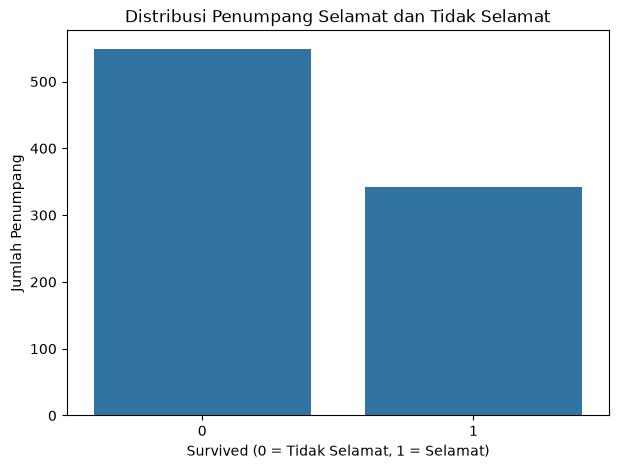

In [5]:
# Distribusi target survived

print("=== Distribusi Target ===")
print(df["survived"].value_counts())

plt.figure(figsize=(7, 5))
sns.countplot(data=df, x="survived")
plt.title("Distribusi Penumpang Selamat dan Tidak Selamat")
plt.xlabel("Survived (0 = Tidak Selamat, 1 = Selamat)")
plt.ylabel("Jumlah Penumpang")
plt.show()

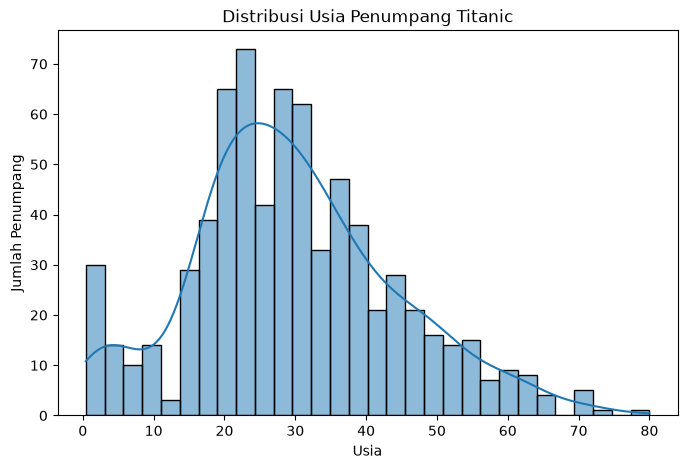

In [6]:
# Distribusi usia penumpang

plt.figure(figsize=(8, 5))
sns.histplot(data=df, x="age", bins=30, kde=True)
plt.title("Distribusi Usia Penumpang Titanic")
plt.xlabel("Usia")
plt.ylabel("Jumlah Penumpang")
plt.show()

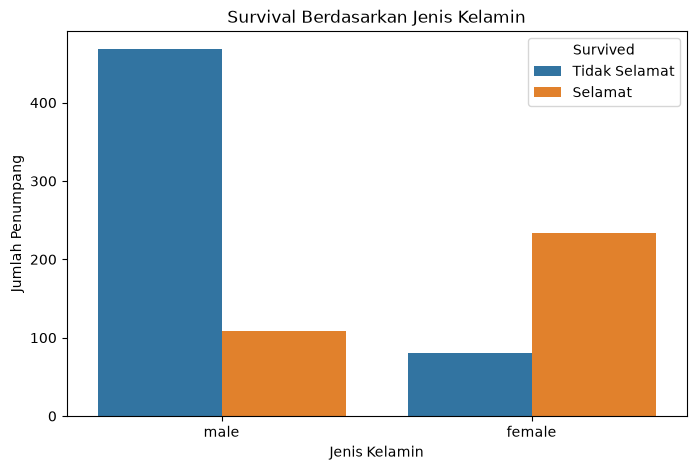

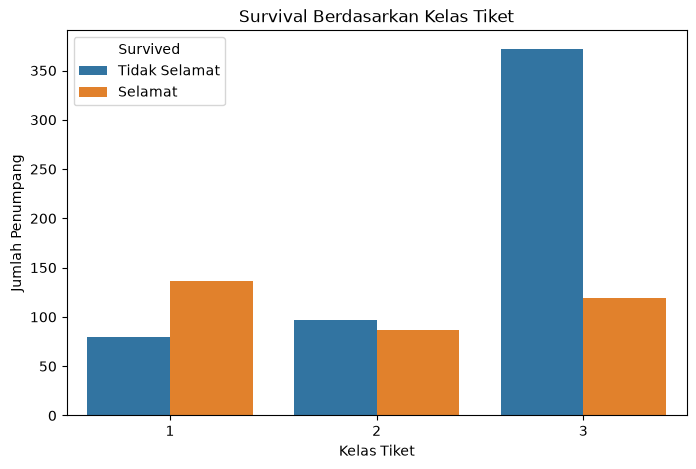

In [7]:
# Survival berdasarkan jenis kelamin

plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="sex", hue="survived")
plt.title("Survival Berdasarkan Jenis Kelamin")
plt.xlabel("Jenis Kelamin")
plt.ylabel("Jumlah Penumpang")
plt.legend(title="Survived", labels=["Tidak Selamat", "Selamat"])
plt.show()

# Survival berdasarkan kelas tiket

plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="pclass", hue="survived")
plt.title("Survival Berdasarkan Kelas Tiket")
plt.xlabel("Kelas Tiket")
plt.ylabel("Jumlah Penumpang")
plt.legend(title="Survived", labels=["Tidak Selamat", "Selamat"])
plt.show()

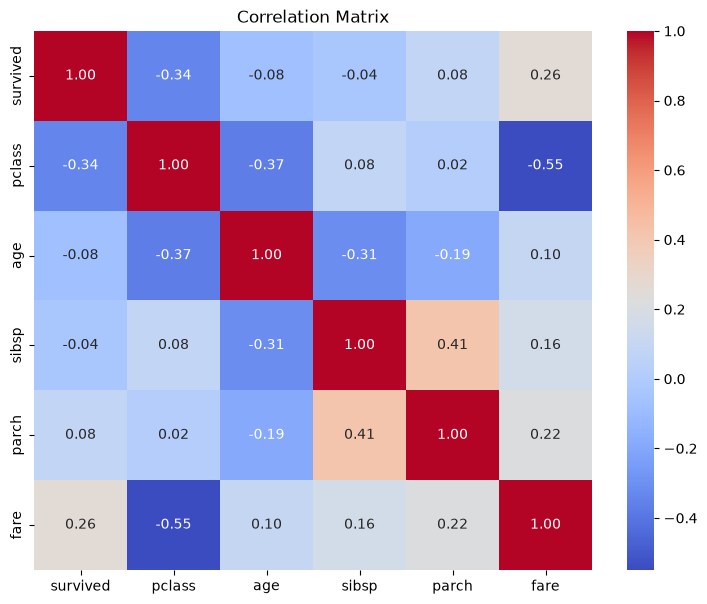

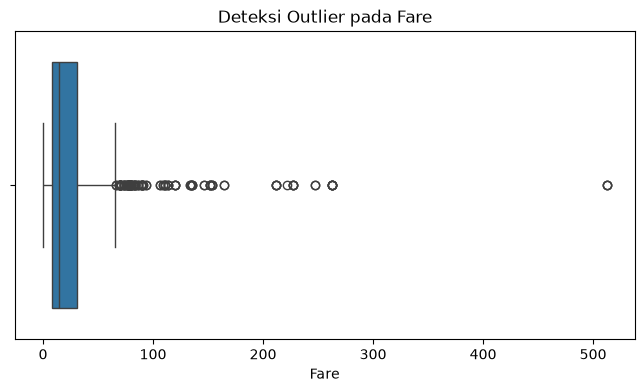

In [8]:
# Korelasi fitur numerik

numeric_cols = [
    "survived",
    "pclass",
    "age",
    "sibsp",
    "parch",
    "fare"
]

correlation_matrix = df[numeric_cols].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)
plt.title("Correlation Matrix")
plt.show()

# Pemeriksaan outlier pada Fare

plt.figure(figsize=(8, 4))
sns.boxplot(data=df, x="fare")
plt.title("Deteksi Outlier pada Fare")
plt.xlabel("Fare")
plt.show()

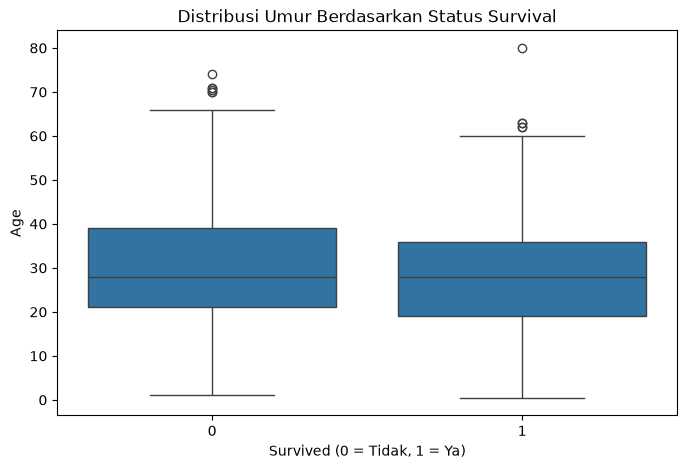

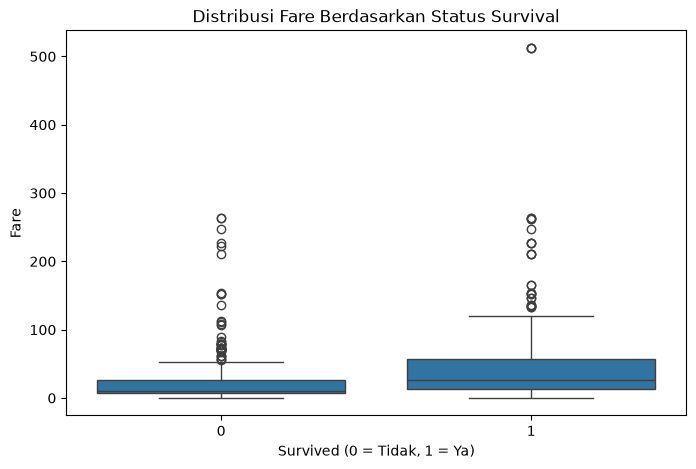

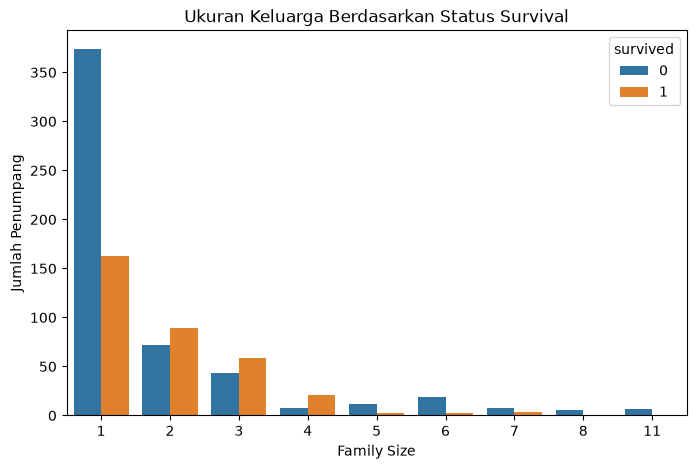

In [9]:
# Bivariate Analysis: hubungan beberapa fitur dengan survival

plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="survived", y="age")
plt.title("Distribusi Umur Berdasarkan Status Survival")
plt.xlabel("Survived (0 = Tidak, 1 = Ya)")
plt.ylabel("Age")
plt.show()

plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="survived", y="fare")
plt.title("Distribusi Fare Berdasarkan Status Survival")
plt.xlabel("Survived (0 = Tidak, 1 = Ya)")
plt.ylabel("Fare")
plt.show()

df["family_size"] = df["sibsp"] + df["parch"] + 1

plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="family_size", hue="survived")
plt.title("Ukuran Keluarga Berdasarkan Status Survival")
plt.xlabel("Family Size")
plt.ylabel("Jumlah Penumpang")
plt.show()

In [10]:
# Ringkasan hasil EDA

print("=== INSIGHT EDA ===")

print("\n1. Target:")
print(df["survived"].value_counts())

print("\n2. Survival berdasarkan jenis kelamin:")
print(pd.crosstab(df["sex"], df["survived"], normalize="index").round(3))

print("\n3. Survival berdasarkan kelas:")
print(pd.crosstab(df["pclass"], df["survived"], normalize="index").round(3))

print("\n4. Rata-rata Fare berdasarkan survival:")
print(df.groupby("survived")["fare"].mean().round(2))

print("\n5. Rata-rata Age berdasarkan survival:")
print(df.groupby("survived")["age"].mean().round(2))

=== INSIGHT EDA ===

1. Target:
survived
0    549
1    342
Name: count, dtype: int64

2. Survival berdasarkan jenis kelamin:
survived      0      1
sex                   
female    0.258  0.742
male      0.811  0.189

3. Survival berdasarkan kelas:
survived      0      1
pclass                
1         0.370  0.630
2         0.527  0.473
3         0.758  0.242

4. Rata-rata Fare berdasarkan survival:
survived
0    22.12
1    48.40
Name: fare, dtype: float64

5. Rata-rata Age berdasarkan survival:
survived
0    30.63
1    28.34
Name: age, dtype: float64


In [11]:
# Membuat dataset untuk modeling

df_model = df.copy()

# Menghapus kolom yang tidak digunakan
drop_columns = [
    "survived",       # target
    "alive",          # sama dengan target
    "deck",           # terlalu banyak missing value
    "embark_town",    # redundant dengan embarked
    "who",            # redundant
    "adult_male",     # redundant
    "alone",          # digantikan oleh fitur is_alone
    "class"           # redundant dengan pclass
]

df_model = df_model.drop(columns=drop_columns)

# Membuat fitur tambahan
df_model["family_size"] = df_model["sibsp"] + df_model["parch"] + 1
df_model["is_alone"] = (df_model["family_size"] == 1).astype(int)

# Target
y = df["survived"]

print("Fitur yang digunakan:")
print(df_model.columns.tolist())

print("\nJumlah data:", len(df_model))
print("Jumlah fitur:", df_model.shape[1])

Fitur yang digunakan:
['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'family_size', 'is_alone']

Jumlah data: 891
Jumlah fitur: 9


In [12]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Membagi data menjadi data latih dan data uji
X_train, X_test, y_train, y_test = train_test_split(
    df_model,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Fitur numerik dan kategorikal
numeric_features = [
    "pclass", "age", "sibsp", "parch",
    "fare", "family_size", "is_alone"
]

categorical_features = [
    "sex", "embarked"
]

# Preprocessing numerik
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Preprocessing kategorikal
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

# Menggabungkan preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

print("Data latih :", X_train.shape)
print("Data uji   :", X_test.shape)
print("Preprocessing berhasil dibuat.")

Data latih : (712, 9)
Data uji   : (179, 9)
Preprocessing berhasil dibuat.


In [13]:
print("=== MISSING VALUE DATA LATIH ===")
print(X_train.isnull().sum())

print("\n=== MISSING VALUE DATA UJI ===")
print(X_test.isnull().sum())

print("\n=== INFORMASI PREPROCESSING ===")
print("Age        : missing value diisi median")
print("Embarked   : missing value diisi modus")
print("Numerik    : menggunakan StandardScaler")
print("Kategorikal: menggunakan OneHotEncoder")
print("Data tidak dihapus karena missing value.")
print("Outlier Fare dipertahankan karena dapat mewakili penumpang kelas tertentu.")

=== MISSING VALUE DATA LATIH ===
pclass           0
sex              0
age            137
sibsp            0
parch            0
fare             0
embarked         2
family_size      0
is_alone         0
dtype: int64

=== MISSING VALUE DATA UJI ===
pclass          0
sex             0
age            40
sibsp           0
parch           0
fare            0
embarked        0
family_size     0
is_alone        0
dtype: int64

=== INFORMASI PREPROCESSING ===
Age        : missing value diisi median
Embarked   : missing value diisi modus
Numerik    : menggunakan StandardScaler
Kategorikal: menggunakan OneHotEncoder
Data tidak dihapus karena missing value.
Outlier Fare dipertahankan karena dapat mewakili penumpang kelas tertentu.


In [14]:
# Model 1: Logistic Regression

from sklearn.linear_model import LogisticRegression

model_lr = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=1000, random_state=42))
])

model_lr.fit(X_train, y_train)

y_pred_lr = model_lr.predict(X_test)

print("=== LOGISTIC REGRESSION ===")
print("Accuracy :", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr))
print("Recall   :", recall_score(y_test, y_pred_lr))
print("F1 Score :", f1_score(y_test, y_pred_lr))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr))

=== LOGISTIC REGRESSION ===
Accuracy : 0.8044692737430168
Precision: 0.7833333333333333
Recall   : 0.6811594202898551
F1 Score : 0.7286821705426356

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.88      0.85       110
           1       0.78      0.68      0.73        69

    accuracy                           0.80       179
   macro avg       0.80      0.78      0.79       179
weighted avg       0.80      0.80      0.80       179



In [15]:
# Model 2: Decision Tree

model_dt = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", DecisionTreeClassifier(
        max_depth=5,
        random_state=42
    ))
])

model_dt.fit(X_train, y_train)

y_pred_dt = model_dt.predict(X_test)

print("=== DECISION TREE ===")
print("Accuracy :", accuracy_score(y_test, y_pred_dt))
print("Precision:", precision_score(y_test, y_pred_dt))
print("Recall   :", recall_score(y_test, y_pred_dt))
print("F1 Score :", f1_score(y_test, y_pred_dt))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_dt))

=== DECISION TREE ===
Accuracy : 0.7653631284916201
Precision: 0.7547169811320755
Recall   : 0.5797101449275363
F1 Score : 0.6557377049180327

Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.88      0.82       110
           1       0.75      0.58      0.66        69

    accuracy                           0.77       179
   macro avg       0.76      0.73      0.74       179
weighted avg       0.76      0.77      0.76       179



In [16]:
# Model 3: Random Forest

model_rf = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ))
])

model_rf.fit(X_train, y_train)

y_pred_rf = model_rf.predict(X_test)

print("=== RANDOM FOREST ===")
print("Accuracy :", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall   :", recall_score(y_test, y_pred_rf))
print("F1 Score :", f1_score(y_test, y_pred_rf))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

=== RANDOM FOREST ===
Accuracy : 0.8100558659217877
Precision: 0.7868852459016393
Recall   : 0.6956521739130435
F1 Score : 0.7384615384615385

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.88      0.85       110
           1       0.79      0.70      0.74        69

    accuracy                           0.81       179
   macro avg       0.80      0.79      0.79       179
weighted avg       0.81      0.81      0.81       179



In [17]:
# Membandingkan performa ketiga model

results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_rf)
    ],
    "Precision": [
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_dt),
        precision_score(y_test, y_pred_rf)
    ],
    "Recall": [
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_dt),
        recall_score(y_test, y_pred_rf)
    ],
    "F1 Score": [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_dt),
        f1_score(y_test, y_pred_rf)
    ]
})

results = results.round(4)

display(results)

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.8045,0.7833,0.6812,0.7287
1,Decision Tree,0.7654,0.7547,0.5797,0.6557
2,Random Forest,0.8101,0.7869,0.6957,0.7385


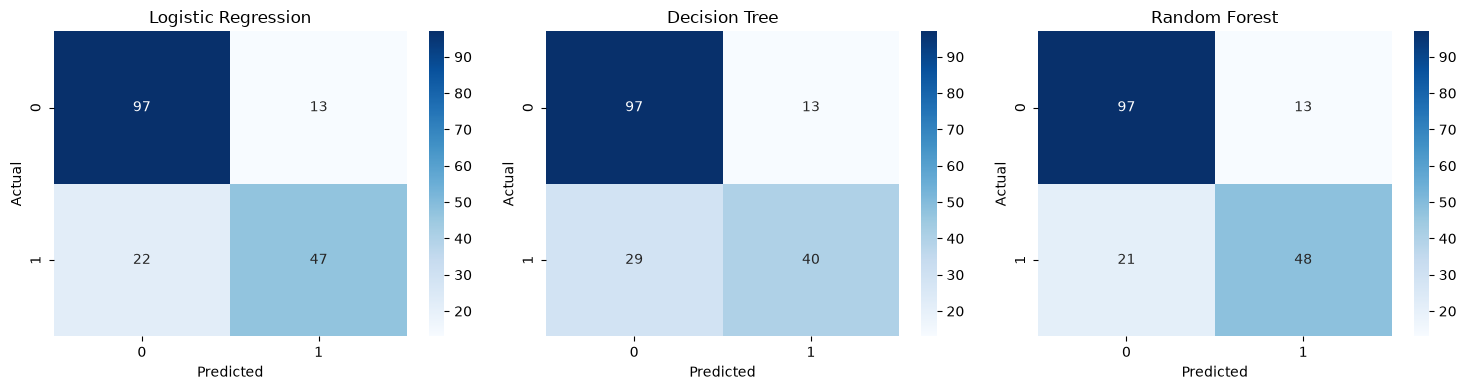

In [18]:
# Confusion Matrix untuk ketiga model

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

cm_lr = confusion_matrix(y_test, y_pred_lr)
cm_dt = confusion_matrix(y_test, y_pred_dt)
cm_rf = confusion_matrix(y_test, y_pred_rf)

sns.heatmap(cm_lr, annot=True, fmt="d", cmap="Blues", ax=axes[0])
axes[0].set_title("Logistic Regression")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

sns.heatmap(cm_dt, annot=True, fmt="d", cmap="Blues", ax=axes[1])
axes[1].set_title("Decision Tree")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Blues", ax=axes[2])
axes[2].set_title("Random Forest")
axes[2].set_xlabel("Predicted")
axes[2].set_ylabel("Actual")

plt.tight_layout()
plt.show()

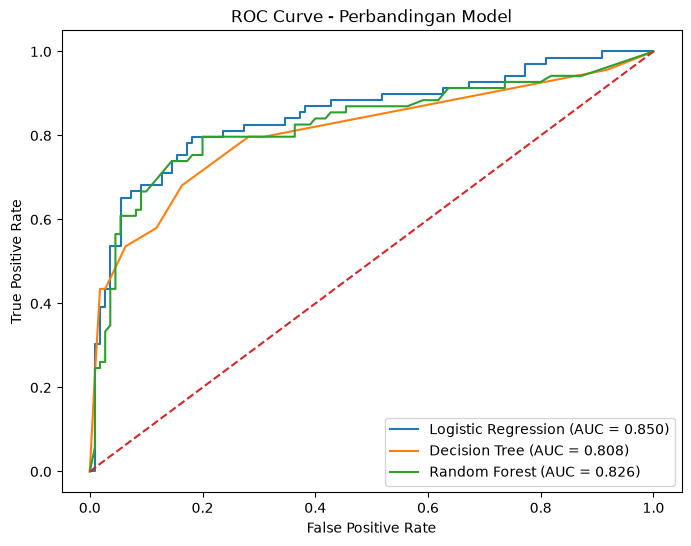

In [19]:
# ROC Curve dan AUC

from sklearn.metrics import roc_curve, auc

models = {
    "Logistic Regression": model_lr,
    "Decision Tree": model_dt,
    "Random Forest": model_rf
}

plt.figure(figsize=(8, 6))

for name, model in models.items():
    y_prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Perbandingan Model")
plt.legend()
plt.show()

In [20]:
# Menghitung nilai AUC

print("=== NILAI AUC ===")

for name, model in models.items():
    y_prob = model.predict_proba(X_test)[:, 1]
    auc_score = roc_auc_score(y_test, y_prob)
    print(f"{name}: {auc_score:.4f}")

=== NILAI AUC ===
Logistic Regression: 0.8505
Decision Tree: 0.8080
Random Forest: 0.8264


In [21]:
from sklearn.model_selection import GridSearchCV

# Pipeline Random Forest untuk tuning
rf_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(random_state=42))
])

# Parameter yang akan diuji
param_grid = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [3, 5, 10, None],
    "model__min_samples_split": [2, 5]
}

grid_search = GridSearchCV(
    rf_pipeline,
    param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("GridSearch selesai.")
print("Parameter terbaik:")
print(grid_search.best_params_)
print("\nBest CV F1 Score:", grid_search.best_score_)

GridSearch selesai.
Parameter terbaik:
{'model__max_depth': 10, 'model__min_samples_split': 5, 'model__n_estimators': 200}

Best CV F1 Score: 0.7529241705712678


In [22]:
# Model Random Forest terbaik hasil GridSearch

best_rf = grid_search.best_estimator_

y_pred_best = best_rf.predict(X_test)

print("=== RANDOM FOREST SETELAH TUNING ===")
print("Accuracy :", accuracy_score(y_test, y_pred_best))
print("Precision:", precision_score(y_test, y_pred_best))
print("Recall   :", recall_score(y_test, y_pred_best))
print("F1 Score :", f1_score(y_test, y_pred_best))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_best))

=== RANDOM FOREST SETELAH TUNING ===
Accuracy : 0.8044692737430168
Precision: 0.7931034482758621
Recall   : 0.6666666666666666
F1 Score : 0.7244094488188977

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.89      0.85       110
           1       0.79      0.67      0.72        69

    accuracy                           0.80       179
   macro avg       0.80      0.78      0.79       179
weighted avg       0.80      0.80      0.80       179



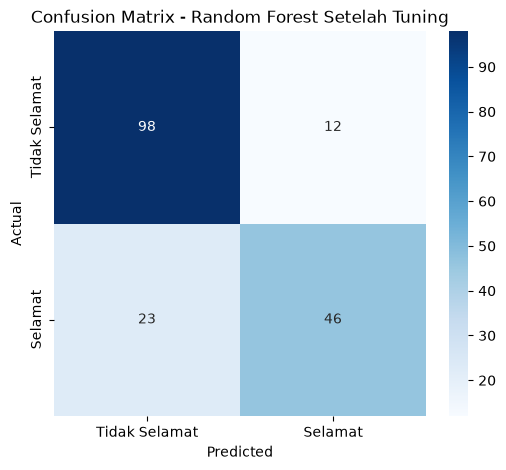

In [23]:
# Confusion Matrix Random Forest setelah tuning

cm_best = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_best,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Tidak Selamat", "Selamat"],
    yticklabels=["Tidak Selamat", "Selamat"]
)

plt.title("Confusion Matrix - Random Forest Setelah Tuning")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

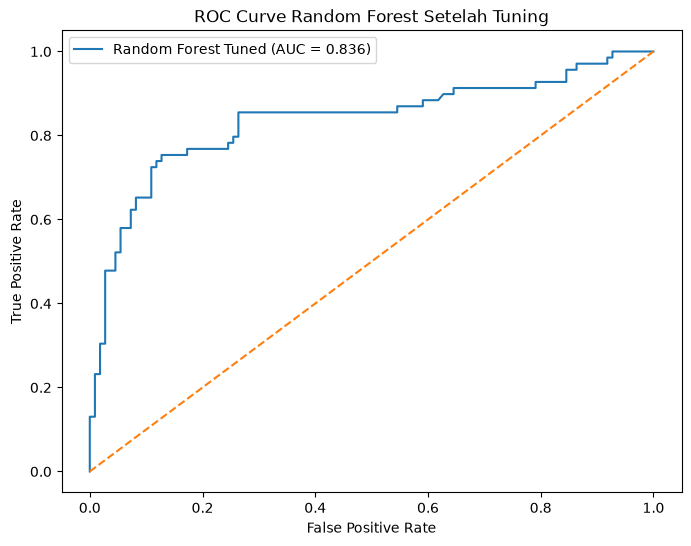

AUC Random Forest Tuned: 0.8358


In [24]:
# ROC Curve Random Forest setelah tuning

y_prob_best = best_rf.predict_proba(X_test)[:, 1]

fpr, tpr, _ = roc_curve(y_test, y_prob_best)
auc_best = roc_auc_score(y_test, y_prob_best)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"Random Forest Tuned (AUC = {auc_best:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Random Forest Setelah Tuning")
plt.legend()
plt.show()

print("AUC Random Forest Tuned:", round(auc_best, 4))

In [25]:
# Feature importance Random Forest

rf_model = best_rf.named_steps["model"]
preprocessor_fitted = best_rf.named_steps["preprocessor"]

feature_names = preprocessor_fitted.get_feature_names_out()
importances = rf_model.feature_importances_

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values("Importance", ascending=False)

display(feature_importance.head(10))

,Feature,Importance
4,num__fare,0.203276
8,cat__sex_male,0.201335
1,num__age,0.173536
7,cat__sex_female,0.163276
0,num__pclass,0.105011
5,num__family_size,0.050690
2,num__sibsp,0.026565
3,num__parch,0.023874
11,cat__embarked_S,0.018252
6,num__is_alone,0.013564


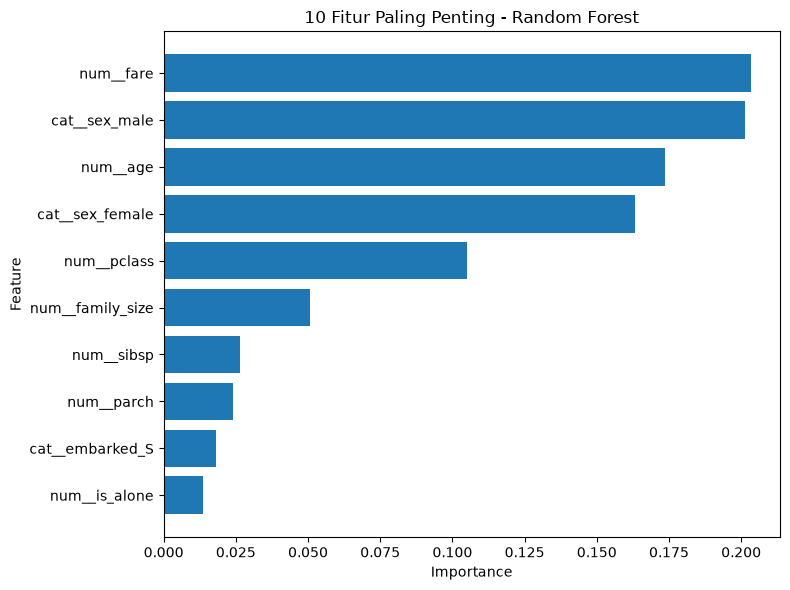

In [26]:
# Visualisasi 10 fitur paling penting

top_features = feature_importance.head(10).sort_values("Importance")

plt.figure(figsize=(8, 6))
plt.barh(top_features["Feature"], top_features["Importance"])

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("10 Fitur Paling Penting - Random Forest")
plt.tight_layout()
plt.show()

In [27]:
# Perbandingan Random Forest sebelum dan sesudah tuning

comparison_rf = pd.DataFrame({
    "Model": [
        "Random Forest Sebelum Tuning",
        "Random Forest Setelah Tuning"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_best)
    ],
    "Precision": [
        precision_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_best)
    ],
    "Recall": [
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_best)
    ],
    "F1 Score": [
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_best)
    ]
})

display(comparison_rf.round(4))

,Model,Accuracy,Precision,Recall,F1 Score
0,Random Forest Sebelum Tuning,0.8101,0.7869,0.6957,0.7385
1,Random Forest Setelah Tuning,0.8045,0.7931,0.6667,0.7244


In [28]:
print("=== KESIMPULAN MODELING ===\n")

print("1. Tiga model yang dibandingkan adalah:")
print("   - Logistic Regression")
print("   - Decision Tree")
print("   - Random Forest")

print("\n2. Berdasarkan hasil evaluasi awal, Random Forest memberikan")
print("   performa terbaik dibandingkan Logistic Regression dan Decision Tree.")

print("\n3. Random Forest kemudian dilakukan tuning menggunakan GridSearchCV")
print("   dengan 5-fold cross validation.")

print("\n4. Parameter terbaik dipilih berdasarkan nilai F1 Score.")

print("\n5. Model Random Forest hasil tuning digunakan sebagai model final")
print("   untuk memprediksi kemungkinan penumpang Titanic selamat.")

=== KESIMPULAN MODELING ===

1. Tiga model yang dibandingkan adalah:
   - Logistic Regression
   - Decision Tree
   - Random Forest

2. Berdasarkan hasil evaluasi awal, Random Forest memberikan
   performa terbaik dibandingkan Logistic Regression dan Decision Tree.

3. Random Forest kemudian dilakukan tuning menggunakan GridSearchCV
   dengan 5-fold cross validation.

4. Parameter terbaik dipilih berdasarkan nilai F1 Score.

5. Model Random Forest hasil tuning digunakan sebagai model final
   untuk memprediksi kemungkinan penumpang Titanic selamat.


In [29]:
# Tabel hasil akhir semua model

final_results = results.copy()

final_results.loc[len(final_results)] = [
    "Random Forest Tuned",
    accuracy_score(y_test, y_pred_best),
    precision_score(y_test, y_pred_best),
    recall_score(y_test, y_pred_best),
    f1_score(y_test, y_pred_best)
]

final_results = final_results.round(4)

display(final_results)

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.8045,0.7833,0.6812,0.7287
1,Decision Tree,0.7654,0.7547,0.5797,0.6557
2,Random Forest,0.8101,0.7869,0.6957,0.7385
3,Random Forest Tuned,0.8045,0.7931,0.6667,0.7244


In [30]:
print("""
=== KESIMPULAN AKHIR ===

1. Dataset Titanic memiliki 891 data dan memenuhi syarat minimal
   500 data serta lebih dari 5 fitur.

2. EDA menunjukkan bahwa jenis kelamin, kelas penumpang, umur,
   tarif, dan ukuran keluarga memiliki hubungan dengan peluang
   keselamatan penumpang.

3. Tiga algoritma yang digunakan adalah Logistic Regression,
   Decision Tree, dan Random Forest.

4. Dari hasil pengujian awal, Random Forest memberikan performa
   terbaik dengan Accuracy 81.01% dan F1 Score 73.85%.

5. Random Forest kemudian dilakukan tuning menggunakan GridSearchCV
   dengan 5-fold cross validation.

6. Model hasil tuning digunakan sebagai model final untuk prediksi
   keselamatan penumpang.

7. Hasil model menunjukkan bahwa machine learning dapat digunakan
   untuk memprediksi kemungkinan penumpang selamat berdasarkan
   karakteristik penumpang.
""")


=== KESIMPULAN AKHIR ===

1. Dataset Titanic memiliki 891 data dan memenuhi syarat minimal
   500 data serta lebih dari 5 fitur.

2. EDA menunjukkan bahwa jenis kelamin, kelas penumpang, umur,
   tarif, dan ukuran keluarga memiliki hubungan dengan peluang
   keselamatan penumpang.

3. Tiga algoritma yang digunakan adalah Logistic Regression,
   Decision Tree, dan Random Forest.

4. Dari hasil pengujian awal, Random Forest memberikan performa
   terbaik dengan Accuracy 81.01% dan F1 Score 73.85%.

5. Random Forest kemudian dilakukan tuning menggunakan GridSearchCV
   dengan 5-fold cross validation.

6. Model hasil tuning digunakan sebagai model final untuk prediksi
   keselamatan penumpang.

7. Hasil model menunjukkan bahwa machine learning dapat digunakan
   untuk memprediksi kemungkinan penumpang selamat berdasarkan
   karakteristik penumpang.



In [31]:
print("""
=== REKOMENDASI ===

1. Model dapat dikembangkan dengan dataset yang lebih besar.
2. Fitur tambahan dapat digunakan untuk meningkatkan performa model.
3. Hyperparameter model dapat dituning lebih luas.
4. Model dapat diterapkan pada sistem prediksi berbasis web.

=== KETERBATASAN ===

1. Dataset Titanic merupakan dataset historis.
2. Beberapa fitur memiliki missing value.
3. Data tidak terlalu besar sehingga hasil model masih dapat berubah
   jika menggunakan pembagian data yang berbeda.
4. Model hanya menggunakan fitur yang tersedia pada dataset.
""")


=== REKOMENDASI ===

1. Model dapat dikembangkan dengan dataset yang lebih besar.
2. Fitur tambahan dapat digunakan untuk meningkatkan performa model.
3. Hyperparameter model dapat dituning lebih luas.
4. Model dapat diterapkan pada sistem prediksi berbasis web.

=== KETERBATASAN ===

1. Dataset Titanic merupakan dataset historis.
2. Beberapa fitur memiliki missing value.
3. Data tidak terlalu besar sehingga hasil model masih dapat berubah
   jika menggunakan pembagian data yang berbeda.
4. Model hanya menggunakan fitur yang tersedia pada dataset.



In [32]:
print("""
=== CHECKLIST UTS MINI PROJECT ===

[✓] Dataset minimal 500 baris
[✓] Minimal 5 fitur
[✓] Problem classification
[✓] Data understanding
[✓] Missing value analysis
[✓] Target distribution
[✓] Correlation analysis
[✓] Minimal 3 univariate analysis
[✓] Minimal 3 bivariate analysis
[✓] Minimal 5 visualisasi
[✓] Preprocessing
[✓] Encoding data kategorikal
[✓] Scaling data numerik
[✓] Train-test split
[✓] Minimal 3 model
[✓] Confusion matrix
[✓] Accuracy
[✓] Precision
[✓] Recall
[✓] F1 Score
[✓] ROC dan AUC
[✓] GridSearchCV
[✓] Model final
[✓] Kesimpulan
[✓] Rekomendasi
[✓] Keterbatasan
""")


=== CHECKLIST UTS MINI PROJECT ===

[✓] Dataset minimal 500 baris
[✓] Minimal 5 fitur
[✓] Problem classification
[✓] Data understanding
[✓] Missing value analysis
[✓] Target distribution
[✓] Correlation analysis
[✓] Minimal 3 univariate analysis
[✓] Minimal 3 bivariate analysis
[✓] Minimal 5 visualisasi
[✓] Preprocessing
[✓] Encoding data kategorikal
[✓] Scaling data numerik
[✓] Train-test split
[✓] Minimal 3 model
[✓] Confusion matrix
[✓] Accuracy
[✓] Precision
[✓] Recall
[✓] F1 Score
[✓] ROC dan AUC
[✓] GridSearchCV
[✓] Model final
[✓] Kesimpulan
[✓] Rekomendasi
[✓] Keterbatasan



In [33]:
print("""
==================================================
UTS MINI PROJECT - APPLIED MACHINE LEARNING
==================================================

Nama       : MUH. ALI IMRAN
NIM        : 105841113523
Program    : Informatika
Mata Kuliah: Applied Machine Learning

Judul:
Titanic Survival Prediction Menggunakan
Machine Learning Classification

Model:
Logistic Regression
Decision Tree
Random Forest

Model Final:
Random Forest dengan GridSearchCV

==================================================
SELESAI
==================================================
""")


UTS MINI PROJECT - APPLIED MACHINE LEARNING

Nama       : MUH. ALI IMRAN
NIM        : 105841113523
Program    : Informatika
Mata Kuliah: Applied Machine Learning

Judul:
Titanic Survival Prediction Menggunakan
Machine Learning Classification

Model:
Logistic Regression
Decision Tree
Random Forest

Model Final:
Random Forest dengan GridSearchCV

SELESAI



## Sumber Dataset

Dataset yang digunakan adalah dataset Titanic dari Seaborn.

Sumber dataset:
https://github.com/mwaskom/seaborn-data/blob/master/titanic.csv

Dataset terdiri dari 891 baris data dan beberapa fitur yang
digunakan untuk memprediksi apakah penumpang selamat atau tidak.

In [34]:
# Ringkasan performa model final

final_accuracy = accuracy_score(y_test, y_pred_best)
final_precision = precision_score(y_test, y_pred_best)
final_recall = recall_score(y_test, y_pred_best)
final_f1 = f1_score(y_test, y_pred_best)

print("========================================")
print("       HASIL MODEL FINAL")
print("========================================")
print(f"Accuracy : {final_accuracy:.4f} ({final_accuracy*100:.2f}%)")
print(f"Precision: {final_precision:.4f} ({final_precision*100:.2f}%)")
print(f"Recall   : {final_recall:.4f} ({final_recall*100:.2f}%)")
print(f"F1 Score : {final_f1:.4f} ({final_f1*100:.2f}%)")
print(f"AUC      : {auc_best:.4f} ({auc_best*100:.2f}%)")
print("========================================")

       HASIL MODEL FINAL
Accuracy : 0.8045 (80.45%)
Precision: 0.7931 (79.31%)
Recall   : 0.6667 (66.67%)
F1 Score : 0.7244 (72.44%)
AUC      : 0.8358 (83.58%)


## Pernyataan Akhir

Berdasarkan hasil eksperimen, Random Forest dipilih sebagai model
final karena memberikan performa terbaik dibandingkan model lainnya.

Proses preprocessing, pemodelan, evaluasi, dan hyperparameter tuning
telah dilakukan untuk mendapatkan model yang lebih baik.

Hasil penelitian menunjukkan bahwa karakteristik seperti jenis
kelamin, kelas penumpang, umur, tarif, dan ukuran keluarga dapat
membantu dalam memprediksi keselamatan penumpang Titanic.

Model ini masih dapat dikembangkan dengan dataset yang lebih besar,
fitur tambahan, serta metode tuning yang lebih luas.

In [35]:
print("==========================================")
print("          FINAL CHECK UTS")
print("==========================================")

print("Dataset       : Titanic")
print("Jumlah data   :", len(df))
print("Jumlah fitur  :", df_model.shape[1])
print("Model         : 3 model classification")
print("Model final   : Random Forest Tuned")
print("GridSearchCV  : ✓")
print("Confusion     : ✓")
print("Accuracy      : ✓")
print("Precision     : ✓")
print("Recall        : ✓")
print("F1 Score      : ✓")
print("ROC / AUC     : ✓")
print("Kesimpulan    : ✓")
print("Rekomendasi   : ✓")
print("Keterbatasan  : ✓")
print("==========================================")
print("NOTEBOOK UTS SELESAI")
print("==========================================")

          FINAL CHECK UTS
Dataset       : Titanic
Jumlah data   : 891
Jumlah fitur  : 9
Model         : 3 model classification
Model final   : Random Forest Tuned
GridSearchCV  : ✓
Confusion     : ✓
Accuracy      : ✓
Precision     : ✓
Recall        : ✓
F1 Score      : ✓
ROC / AUC     : ✓
Kesimpulan    : ✓
Rekomendasi   : ✓
Keterbatasan  : ✓
NOTEBOOK UTS SELESAI
